In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, applications

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "muratkokludataset/pistachio-image-dataset"
)

print("\nPath to dataset files:")
print(path)

100%|██████████| 26.7M/26.7M [00:00<00:00, 107MB/s] 

Extracting files...



Path to dataset files:
/root/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1


In [3]:
print("\nSearching dataset folders...")

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)

    if level <= 2:
        print(root)



dataset_path = None

for root, dirs, files in os.walk(path):

    if len(dirs) >= 2:

        valid_class_folders = 0

        for d in dirs:
            folder = os.path.join(root, d)

            try:
                files_inside = os.listdir(folder)

                image_count = sum(
                    1
                    for f in files_inside
                    if f.lower().endswith(
                        (".jpg", ".jpeg", ".png", ".bmp")
                    )
                )

                if image_count > 0:
                    valid_class_folders += 1

            except:
                pass

        if valid_class_folders >= 2:
            dataset_path = root
            break

print("\nDataset path:")
print(dataset_path)

if dataset_path is None:
    raise FileNotFoundError(
        "Could not automatically find the image dataset folder."
    )


Searching dataset folders...
/root/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1
/root/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1/Pistachio_Image_Dataset
/root/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1/Pistachio_Image_Dataset/Pistachio_Image_Dataset
/root/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1/Pistachio_Image_Dataset/Pistachio_16_Features_Dataset
/root/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1/Pistachio_Image_Dataset/Pistachio_28_Features_Dataset

Dataset path:
/root/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1/Pistachio_Image_Dataset/Pistachio_Image_Dataset


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

mean = tf.constant([0.485, 0.456, 0.406])
std = tf.constant([0.229, 0.224, 0.225])

def process_image(image, label):
    # Scale from [0, 255] to [0.0, 1.0]
    image = tf.cast(image, tf.float32) / 255.0
    # Normalize with ImageNet mean and std
    image = (image - mean) / std
    return image, label

In [5]:
# TensorFlow's image_dataset_from_directory handles loading, splitting,
# and batching all at once.

print("\nLoading Training Data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nLoading Testing Data...")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

print("\nClasses:")
print(class_names)


# Apply the normalization and prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(process_image, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

test_dataset = test_dataset.map(process_image, num_parallel_calls=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("\nDataLoaders created and normalized successfully.")

NUM_CLASSES = len(class_names)

print(
    "\nNumber of classes:",
    NUM_CLASSES
)


Loading Training Data...
Found 2148 files belonging to 2 classes.
Using 1719 files for training.

Loading Testing Data...
Found 2148 files belonging to 2 classes.
Using 429 files for validation.

Classes:
['Kirmizi_Pistachio', 'Siirt_Pistachio']

DataLoaders created and normalized successfully.

Number of classes: 2


In [6]:
# LOAD ALEXNET (CUSTOM BUILD)

print("\nBuilding AlexNet...")

# Keras does not have AlexNet built-in, so we construct it.
# (Note: This will train from scratch, unlike PyTorch's pretrained version)
alexnet = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(96, 11, strides=4, padding='same', activation='relu'),
    layers.MaxPooling2D(3, strides=2),
    layers.Conv2D(256, 5, padding='same', activation='relu'),
    layers.MaxPooling2D(3, strides=2),
    layers.Conv2D(384, 3, padding='same', activation='relu'),
    layers.Conv2D(384, 3, padding='same', activation='relu'),
    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(3, strides=2),
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

print("AlexNet built successfully.")


Building AlexNet...
AlexNet built successfully.


In [7]:
# LOAD VGG16

print("\nLoading VGG16...")

vgg16_base = applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze feature layers
vgg16_base.trainable = False

vgg16 = models.Sequential([
    vgg16_base,
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

print("VGG16 loaded successfully.")


Loading VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded successfully.


In [8]:
# LOAD RESNET50

print("\nLoading ResNet50...")

resnet50_base = applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all pretrained layers
resnet50_base.trainable = False

resnet50 = models.Sequential([
    resnet50_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

print("ResNet50 loaded successfully.")


Loading ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 loaded successfully.


In [9]:
# LOAD EFFICIENTNETB0

print("\nLoading EfficientNetB0...")

efficientnet_base = applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze feature layers
efficientnet_base.trainable = False

efficientnet = models.Sequential([
    efficientnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

print("EfficientNetB0 loaded successfully.")


Loading EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 loaded successfully.


In [10]:
models_dict = {

    "AlexNet": alexnet,

    "VGG16": vgg16,

    "ResNet50": resnet50,

    "EfficientNetB0": efficientnet

}


def train_model(
    model,
    model_name,
    epochs=10
):

    print("\n")
    print("=" * 60)
    print("Training:", model_name)
    print("=" * 60)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start_time = time.time()

    # Keras fits the model and returns a history object natively
    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=epochs,
        verbose=1
    )

    training_time = (
        time.time() - start_time
    )

    print(
        f"\n{model_name} completed in "
        f"{training_time / 60:.2f} minutes."
    )

    # Restructure history to match the requested dictionary layout
    formatted_history = {
        "train_loss": history.history['loss'],
        "train_accuracy": [acc * 100 for acc in history.history['accuracy']],
        "test_loss": history.history['val_loss'],
        "test_accuracy": [acc * 100 for acc in history.history['val_accuracy']]
    }

    return (
        model,
        formatted_history,
        training_time
    )

In [11]:
EPOCHS = 10

results = {}

trained_models = {}

for name, model in models_dict.items():

    trained_model, history, training_time = train_model(

        model,

        name,

        epochs=EPOCHS

    )

    trained_models[name] = (
        trained_model
    )

    results[name] = {

        "history": history,

        "training_time":
            training_time

    }

comparison = []

for name, result in results.items():

    history = result["history"]

    comparison.append({

        "Model":
            name,

        "Training Accuracy (%)":
            round(
                history[
                    "train_accuracy"
                ][-1],
                2
            ),

        "Test Accuracy (%)":
            round(
                history[
                    "test_accuracy"
                ][-1],
                2
            ),

        "Test Loss":
            round(
                history[
                    "test_loss"
                ][-1],
                4
            ),

        "Training Time (min)":
            round(
                result[
                    "training_time"
                ] / 60,
                2
            )

    })

comparison_df = pd.DataFrame(
    comparison
)

comparison_df = comparison_df.sort_values(
    by="Test Accuracy (%)",
    ascending=False
)

print("\n")
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

from IPython.display import display
display(comparison_df)



Training: AlexNet
Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.6161 - loss: 1.8644 - val_accuracy: 0.5431 - val_loss: 0.6932
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.5817 - loss: 0.6823 - val_accuracy: 0.5431 - val_loss: 0.6968
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.5812 - loss: 0.6809 - val_accuracy: 0.5431 - val_loss: 0.6942
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5812 - loss: 0.6815 - val_accuracy: 0.5431 - val_loss: 0.6961
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.5812 - loss: 0.6810 - val_accuracy: 0.5431 - val_loss: 0.6941
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.5812 - loss: 0.6831 - val_accuracy: 0.5431 - val_loss: 0.6982
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.5812 - loss: 0.6816 - val_accuracy: 0.5431 - val_loss: 0.6935
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.5812 - 

,Model,Training Accuracy (%),Test Accuracy (%),Test Loss,Training Time (min)
1,VGG16,98.31,96.50,0.1478,2.89
2,ResNet50,91.22,87.88,0.2775,1.57
3,EfficientNetB0,84.82,87.65,0.3095,2.06
0,AlexNet,58.12,54.31,0.6927,1.38


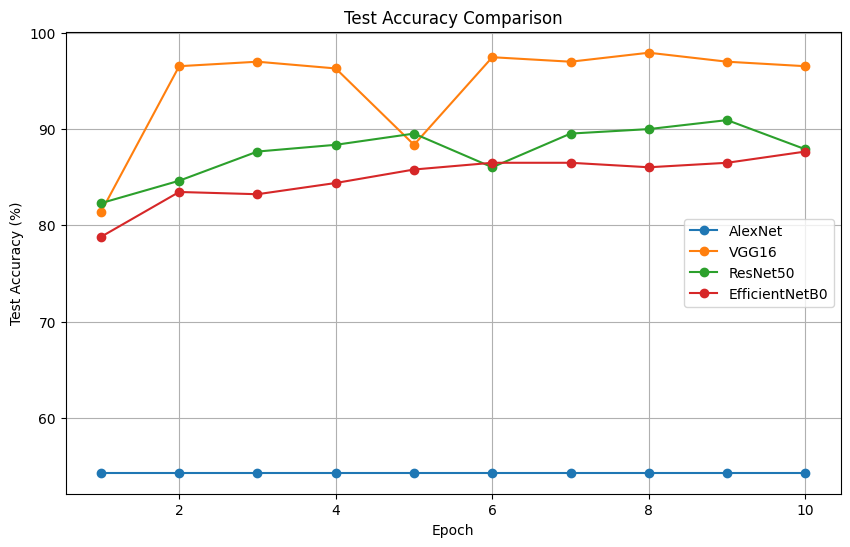

In [12]:
plt.figure(
    figsize=(10, 6)
)

for name, result in results.items():

    plt.plot(

        range(
            1,
            EPOCHS + 1
        ),

        result[
            "history"
        ][
            "test_accuracy"
        ],

        marker="o",

        label=name
    )

plt.xlabel("Epoch")

plt.ylabel(
    "Test Accuracy (%)"
)

plt.title(
    "Test Accuracy Comparison"
)

plt.legend()

plt.grid(True)

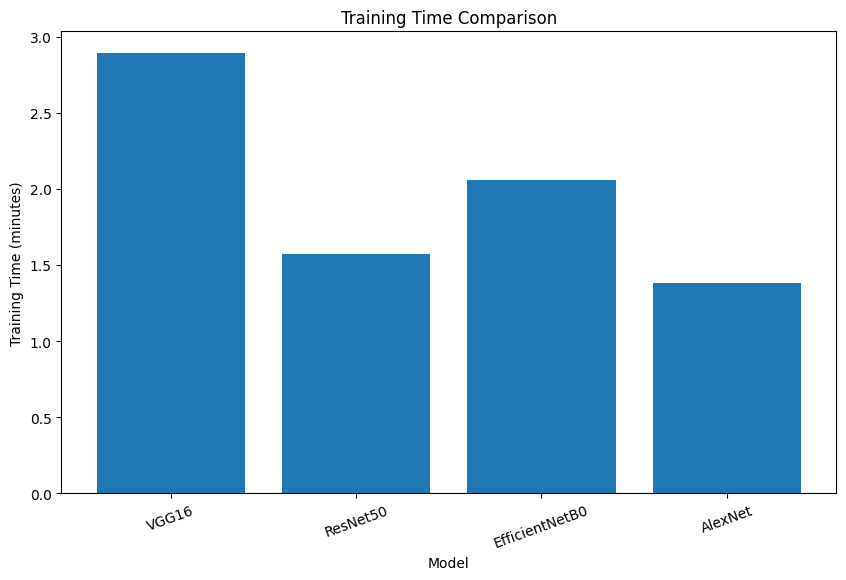

In [13]:
plt.figure(
    figsize=(10, 6)
)

plt.bar(

    comparison_df[
        "Model"
    ],

    comparison_df[
        "Training Time (min)"
    ]

)

plt.xlabel("Model")

plt.ylabel(
    "Training Time (minutes)"
)

plt.title(
    "Training Time Comparison"
)

plt.xticks(
    rotation=20
)

plt.show()


In [14]:
for name, model in trained_models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        + "_pistachio.keras"
    )

    model.save(filename)

    print(
        "Saved:",
        filename
    )



def predict_image(
    image_path,
    model,
    class_names
):

    # Load and render original image for plotting
    original_img = tf.keras.utils.load_img(image_path)

    # Resize image for prediction
    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    img_array = tf.keras.utils.img_to_array(img)

    # Apply identical PyTorch style normalization mapping
    img_array = img_array / 255.0
    img_array = (img_array - mean.numpy()) / std.numpy()

    # Expand dimensions to match batch format
    img_tensor = tf.expand_dims(img_array, 0)

    # Predict
    probabilities = model.predict(img_tensor, verbose=0)[0]

    predicted_idx = np.argmax(probabilities)
    confidence = probabilities[predicted_idx]

    predicted_class = class_names[predicted_idx]

    print(
        "Predicted Class:",
        predicted_class
    )

    print(
        "Confidence:",
        f"{confidence * 100:.2f}%"
    )

    plt.figure(
        figsize=(5, 5)
    )

    plt.imshow(original_img)

    plt.axis("off")

    plt.title(
        f"{predicted_class} "
        f"({confidence * 100:.2f}%)"
    )

    plt.show()

# Example usage (uncomment and replace with a valid local path):
# predict_image("path/to/pistachio_image.jpg", trained_models["ResNet50"], class_names)

Saved: alexnet_pistachio.keras
Saved: vgg16_pistachio.keras
Saved: resnet50_pistachio.keras
Saved: efficientnetb0_pistachio.keras
